In [ ]:
pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 31.1 MB/s eta 0:00:00


In [ ]:
import mysql.connector

--- Basic Sales Summary ---
    product  total_qty  revenue
0  Keyboard         15    675.0
1    Laptop          7   8400.0
2   Monitor         10   3000.0
3     Mouse         30    765.0
---------------------------

Success: 'sales_chart.png' has been saved.


<Figure size 800x500 with 0 Axes>

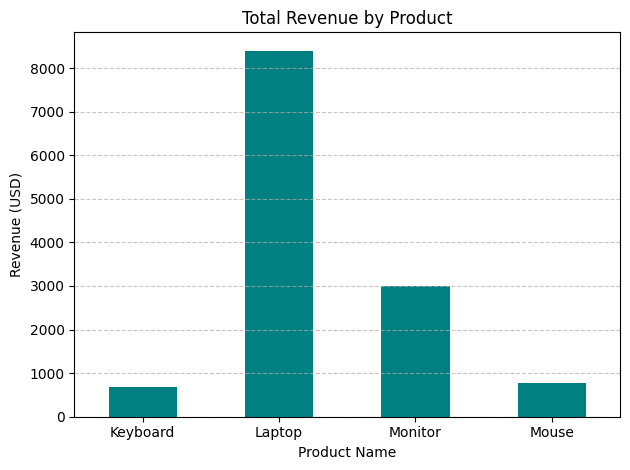

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup: Create the SQLite database and table
# This creates a file named 'sales_data.db' in your current folder
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Clean up any existing table and create a new one
cursor.execute("DROP TABLE IF EXISTS sales")
cursor.execute('''
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

# Insert sample data
sample_data = [
    (1, 'Laptop', 5, 1200.00),
    (2, 'Mouse', 25, 25.50),
    (3, 'Keyboard', 15, 45.00),
    (4, 'Laptop', 2, 1200.00),
    (5, 'Monitor', 10, 300.00),
    (6, 'Mouse', 5, 25.50)
]

cursor.executemany("INSERT INTO sales VALUES (?, ?, ?, ?)", sample_data)
conn.commit()

# 2. Run SQL Query
# We aggregate the data to find totals per product
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# 3. Load into Pandas
df = pd.read_sql_query(query, conn)

# 4. Display Output (Print)
print("--- Basic Sales Summary ---")
print(df)
print("-" * 27)

# 5. Plot simple bar chart
plt.figure(figsize=(8, 5))
df.plot(kind='bar', x='product', y='revenue', color='teal', legend=False)

plt.title('Total Revenue by Product')
plt.xlabel('Product Name')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=0) # Keeps product names horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the chart
plt.savefig("sales_chart.png")
print("\nSuccess: 'sales_chart.png' has been saved.")

# Show the chart
plt.show()

# Close the database connection
conn.close()